## Setup

### Manage Packages

In [47]:
# Import all required packages
import pandas as pd                   # For data manipulation and analysis
#import gurobipy as grb                # Gurobi optimization library for solving mathematical models
import io
import gymnasium as gym

#from gymnasium import spaces
import numpy as np
import os
import pickle
import copy
import random
import time
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import matplotlib.ticker as ticker
import warnings
from concurrent.futures import ProcessPoolExecutor
import multiprocessing
import torch

from tqdm import tqdm
#from sklearn.metrics import mean_squared_error
from scipy.stats import ttest_ind
import seaborn as sns

#from stable_baselines3.common.vec_env import DummyVecEnv  #, VecNormalize #SubprocVecEnv, 
#from stable_baselines3.common.env_util import make_vec_env

#from stable_baselines3.common.env_checker import check_env
#from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback, EvalCallback
#from stable_baselines3.common.monitor import Monitor
#from gymnasium.wrappers import FlattenObservation
#from sb3_contrib.common.maskable.utils import get_action_masks

# Import custom zero counting function
def count_zeros(arr):
    return np.count_nonzero(arr < 0.00001)

# Import custom environment .py file
import env_TA as ce #modified for curriculum learning

### Input Parameters

In [107]:
#User Determined Settings
graphName = "G4x5"  # Graph nodes and edges to use
env_deterministic = False
env_fixed_costs = False
env_initial_budget = None
env_multiple_interdiction = False
env_attacker_strategy = 'zero_sum'  # canalize   isolate   divert

model_name = "G4x5_S_PPO_EX002Z"
model_timesteps = 4536000            # Set a number, 1512000, or  None

### Create Environment, Create Agent, and Load Optimal Solutions

In [108]:
## Create Environment
# Create nodes and edges
node_filename = f"{graphName}_Nodes.csv"  # Dynamically include graphName
edge_filename = f"{graphName}_Edges.csv"  # Dynamically include graphName

nodes, edges = ce.create_nodes_edges(node_filename, edge_filename)

# Load Environment
env = ce.CustomEnv(nodes, edges, deterministic_agent=env_deterministic,
                   multiple_interdiction_attempts=env_multiple_interdiction,
                   attacker_strategy = env_attacker_strategy,
                   initial_budget=env_initial_budget)

## Create Agent
# Get the current working directory
current_dir = os.getcwd()
models_dir = os.path.join(current_dir, '..', 'Trained_RL_Models')

# LOAD Previous saved model
if model_timesteps == None:
    model_path = f"{models_dir}/{model_name}/best_model"
else:
    model_path = f"{models_dir}/{model_name}/{model_name}_{model_timesteps}_steps"
data = np.load(f"{models_dir}/{model_name}/evaluations.npz")

# Load Environment
eval_env = ce.CustomEnv(nodes, edges, deterministic_agent=env_deterministic,
                   multiple_interdiction_attempts=env_multiple_interdiction,
                   attacker_strategy = env_attacker_strategy,
                   initial_budget=env_initial_budget)

#env = DummyVecEnv([lambda: env])

# Load the model
if "PPO" in model_name:
    from sb3_contrib import MaskablePPO
    agent=MaskablePPO.load(model_path, env=env)
elif "PPO" in model_name:
    from stable_baselines3 import PPO
    agent=PPO.load(model_path, env=env)
elif "DQN" in model_name:
    from stable_baselines3 import DQN
    agent=DQN.load(model_path, env=env)
elif "A2C" in model_name:
    from stable_baselines3 import A2C
    agent=A2C.load(model_path, env=env)

## Load Optimal Solutions
#load and Read Pickle File of Backward Induction Solutions
# Use the same path and filename as in your saving code
save_filename = f"{graphName}_{env_attacker_strategy}_solution.pkl"
save_path = os.path.join(current_dir, '..', 'Solutions', save_filename)

# Open the pickle file in binary read mode and load the data
with open(save_path, "rb") as f:
    results = pickle.load(f)

# Now you can access the saved data
print("Episodes completed:", results["last_episode"] + 1)
print("Objective values:", np.mean(results["optimal_obj_vals"]))
print("Interdiction sets:", results["all_optimal_interdiction_edges"])
print("Solution times:", np.mean(results["optimal_solution_times"]))

optimal_obj_vals = results["optimal_obj_vals"]
all_optimal_interdiction_edges = results["all_optimal_interdiction_edges"]
optimal_solution_times = results["optimal_solution_times"]

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Episodes completed: 1000
Objective values: 100.82603571428562
Interdiction sets: [((14, 18), (16, 20)), ((15, 19), (17, 21)), ((14, 18), (16, 20)), ((17, 21),), ((2, 6), (4, 8)), ((11, 15), (12, 16)), ((16, 20), (17, 21)), ((7, 11), (9, 13)), ((16, 20), (17, 21)), ((15, 19), (16, 20)), ((2, 6), (4, 8)), ((7, 11),), ((3, 7),), ((7, 11), (8, 12)), ((14, 18), (15, 19)), ((14, 18), (17, 21)), ((11, 15), (13, 17)), ((15, 19), (16, 20)), ((2, 6), (3, 7)), ((14, 18), (16, 20)), ((9, 13),), ((14, 18), (17, 21)), ((2, 6), (5, 9)), ((2, 6), (3, 7)), ((14, 18),), ((8, 12),), ((14, 18),), ((14, 18), (15, 19)), ((8, 12), (9, 13)), ((14, 18),), ((14, 18),), ((10, 14), (13, 17)), ((15, 19),), ((15, 19), (17, 21)), ((17, 21),), ((8, 12), (9, 13)), ((15, 19),), ((7, 11), (8, 12)), ((14, 18), (16, 20)), ((6, 10), (7, 11)), ((3, 7), (4, 8)), ((16, 20), (17, 21)), ((14, 18), (15, 19)), ((2, 6), (5, 9)), ((14, 18),), ((14, 18), (1

## Analysis

### Plot Training Progress

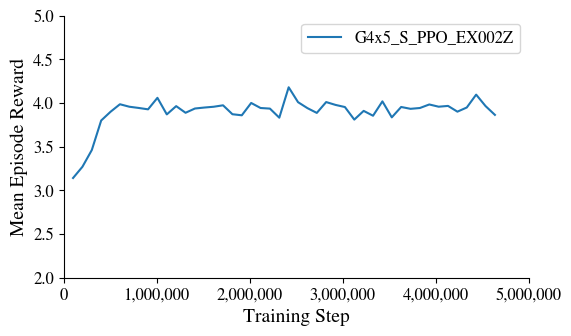

In [109]:
plt.figure(figsize=(6, 3.4))

plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

timesteps = data['timesteps']
results = data['results']
mean_rewards = np.mean(results, axis=1)
plt.plot(timesteps, mean_rewards, label=model_name)

#plt.title('Deterministic Network Interdiction Agent Training')
plt.xlabel('Training Step')
plt.ylabel('Mean Episode Reward')
plt.legend()

#Adjust viewing window
plt.xlim(0000000, 5000000)
plt.ylim(2, 5)

# Set x-axis ticks at each million5
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(1000000))

# Format x-axis tick labels with commas
def format_func(value, tick_number):
    return f"{value:,.0f}"

plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(format_func))

sns.despine()

plt.show()

### Generate Optimal Interdicted Edge Histogram

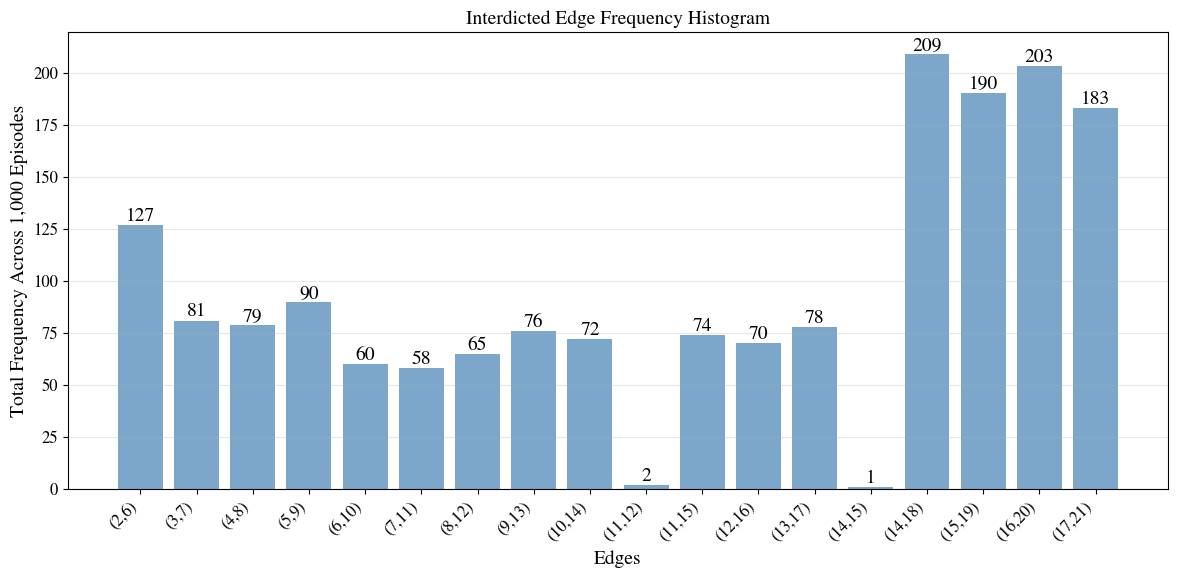

In [105]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

def plot_edge_histogram_from_lists(edge_lists, title="Interdicted Edge Frequency Histogram", figsize=(12, 6), 
                                 combine_all=True, show_individual=False):
    """
    Create a histogram from a list of lists of edges showing frequency of occurrence.
    
    Parameters:
    edge_lists: List of lists, where each inner list contains edge tuples
                e.g., [[(1,2), (2,3)], [(1,2), (3,4)], [(2,3), (1,2)]]
    title: Title for the plot
    figsize: Figure size (width, height)
    combine_all: If True, combines all edges from all lists into one histogram
    show_individual: If True, shows separate histograms for each list
    
    Returns:
    Dictionary with frequency data
    """
    
    if combine_all:
        # Flatten all edge lists into one big list
        all_edges = []
        for edge_list in edge_lists:
            all_edges.extend(edge_list)
        
        # Count occurrences of each edge across all lists
        edge_counts = Counter(all_edges)
        
        # Sort edges for consistent ordering
        sorted_edges = sorted(edge_counts.keys())
        counts = [edge_counts[edge] for edge in sorted_edges]
        edge_labels = [f"({edge[0]},{edge[1]})" for edge in sorted_edges]
        
        # Create the bar plot
        plt.figure(figsize=figsize)
        bars = plt.bar(range(len(edge_labels)), counts, alpha=0.7, color='steelblue')
        
        # Customize the plot
        plt.xlabel('Edges')
        plt.ylabel('Total Frequency Across 1,000 Episodes')
        plt.title(f"{title}")
        plt.xticks(range(len(edge_labels)), edge_labels, rotation=45, ha='right')
        
        # Add value labels on top of bars
        for bar, count in zip(bars, counts):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    str(count), ha='center', va='bottom')
        
        plt.tight_layout()
        plt.grid(axis='y', alpha=0.3)
        plt.show()
        
        return {"combined": edge_counts, "total_edges": len(all_edges), "num_lists": len(edge_lists)}

your_edge_lists = all_optimal_interdiction_edges
plots = plot_edge_histogram_from_lists(your_edge_lists)

### Generate Heatmap of Interdicted Edges on Graph

In [ ]:
# TBD

### Evaluate Agent Performance Against Optimal Solutions

In [110]:
# Test Agent against a range of scenarios
num_of_scenarios = 10

# Pre-compute constants outside the loop
interdictable_edges_list = list(env.interdictable_edges)

# Initialize arrays to store results
max_flow_vals =  np.zeros(num_of_scenarios)
agent_best_rewards = np.zeros(num_of_scenarios)

# Initialize a dictionary to keep track of actions
action_tally = {i: 0 for i in env.interdictable_edges}

all_agent_actions =[]
agent_solution_times = np.zeros(num_of_scenarios)
#optimal_solution_times=[]

def mask_fn(env):
    """
    Function to generate action mask based on your validation logic
    """
    # Get current state
    remaining_budget = env.state['budget']
    
    # Create action mask - size should match action space
    action_mask = np.ones(env.action_space.n, dtype=np.float32)
    
    # Mask interdictable edges (first 25 actions)
    for action in range(min(env.num_interdictable_edges, env.action_space.n)):
        if not env._validate_action(action, remaining_budget, env.state['edge_interdicted']):
            action_mask[action] = 0.0
    
    # The "do nothing" action (if it exists) is typically always valid
    # It should be at index env.num_interdictable_edges
    # No additional masking needed for "do nothing" action
    return action_mask

agent.policy.eval()
torch.no_grad()

for episode in tqdm(range(num_of_scenarios)):
    obs, _ = env.reset(seed=episode)

    #Determine Original Flow
    max_flow_vals[episode] = env.reference_obj

    action_list = []
    action_list_append = action_list.append  # Cache method reference
    
    start_time = time.perf_counter()
    # Run agent with proper normalization
    for _ in range(31):
        action, _ = agent.predict(obs, deterministic=True, action_masks=mask_fn(env))
        # Use wrapper's step method
        obs, reward, done, _, _ = env.step(action)  
        # Tally actions using inner environment
        if action != env.num_interdictable_edges:
            action_key = interdictable_edges_list[action]
            action_tally[action_key] += 1
            action_list_append(action_key)  # Faster than action_list.append()
            
        if done:
            break
    end_time = time.perf_counter()
    agent_solution_times[episode]=(end_time-start_time)
    all_agent_actions.append(frozenset(action_list))

    if all_agent_actions[episode].issuperset(all_optimal_interdiction_edges[episode]):
        objVal = optimal_obj_vals[episode]
    else:
        # Get final objective value from inner environment
        objVal, _ = env._compute_objective_and_flows()

    agent_best_rewards[episode] = objVal

#Print Results
print("Optimal Time to Solve (Mean): ",np.mean(optimal_solution_times[0:num_of_scenarios-1]))
print("")

relative_errors = abs(agent_best_rewards-optimal_obj_vals[0:num_of_scenarios]) / (max_flow_vals-optimal_obj_vals[0:num_of_scenarios])# Create boolean mask using set operations
    
# Calculate mean relative error
mean_relative_error = np.nanmean(relative_errors)
print(model_name, ": ", count_zeros(relative_errors))
print("Mean Relative Error: ", mean_relative_error)
print("RL Time to Solve (Mean): ", np.mean(agent_solution_times))
print("")

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [01:11<00:00,  7.10s/it]

Optimal Time to Solve (Mean):  6.011685764003131

G4x5_S_PPO_EX002Z :  3
Mean Relative Error:  0.20215050996254474
RL Time to Solve (Mean):  5.398829940031282



### Create Visualization of an Episode with Network, Optimal Solution, and Agent Solution
Create a visualization of obs, optimal solution, and agent solution
